# Frequency-Domain Analysis and Histogram Processing in Image Processing
This notebook explores key image processing techniques, particularly frequency-domain transformations and histogram manipulation. We analyze the effects of Fourier transforms, low-pass and high-pass filtering, and histogram equalization on image representation and enhancement. These techniques are widely used in applications such as segmentation, feature extraction, and image restoration.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## 1. Frequency-Domain Analysis with Fourier Transform
### 1.1 Fourier Transform and Spectrum Visualization
The Fourier Transform (FT) converts an image from the spatial domain to the frequency domain, where image structures can be analyzed in terms of their frequency components.

- **Magnitude Spectrum:** Represents the intensity of different frequency components.
- **Phase Spectrum:** Represents the spatial arrangement of these frequency components.

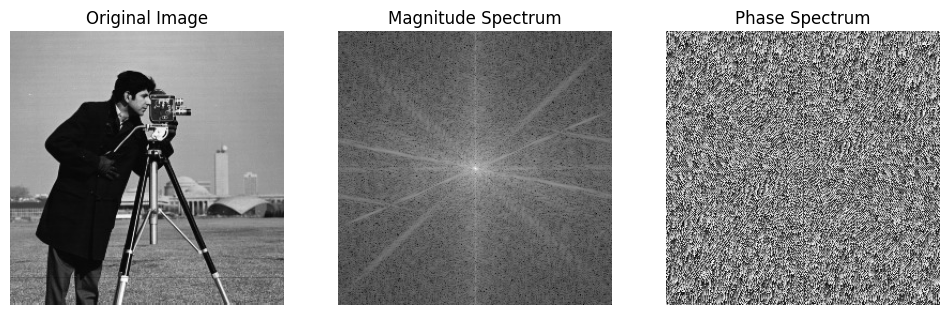

In [25]:
# Load the image in grayscale
img1 = cv2.imread("data/cameraman.jpg", cv2.IMREAD_GRAYSCALE)

# Compute the 2D Fourier Transform
f1 = np.fft.fft2(img1)

# Shift the zero frequency component to the center
fshift1 = np.fft.fftshift(f1)

# Compute magnitude and phase spectra
magnitude_spectrum1 = np.abs(fshift1)
phase_spectrum1 = np.angle(fshift1)

# Display the original image, magnitude spectrum, and phase spectrum
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 8))

ax1.imshow(img1, cmap='gray')
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(np.log1p(magnitude_spectrum1), cmap='gray')  # Log transform for better visualization
ax2.set_title('Magnitude Spectrum')
ax2.axis('off')

ax3.imshow(phase_spectrum1, cmap='gray')
ax3.set_title('Phase Spectrum')
ax3.axis('off')

plt.show()

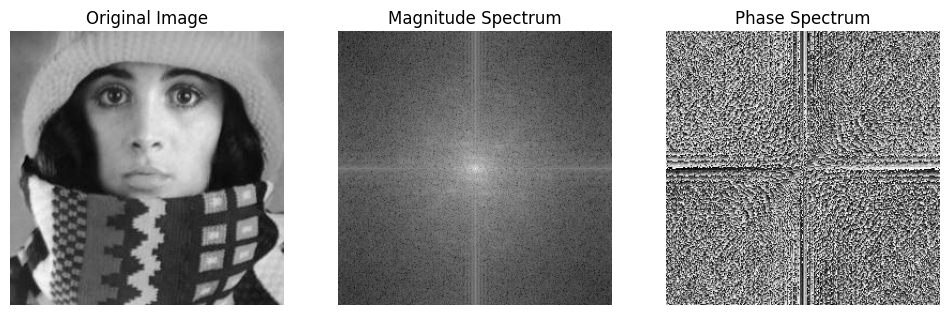

In [24]:
# Load the grayscale image
img2 = cv2.imread("data/trui.png", cv2.IMREAD_GRAYSCALE)

# Compute the 2D Fourier Transform
f2 = np.fft.fft2(img2)

# Shift zero frequency component to the center
fshift2 = np.fft.fftshift(f2)

# Compute magnitude and phase spectra
magnitude_spectrum2 = np.abs(fshift2)
phase_spectrum2 = np.angle(fshift2)

# Display the original image, magnitude spectrum, and phase spectrum
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 8))

ax1.imshow(img2, cmap='gray')
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(np.log(1 + magnitude_spectrum2), cmap='gray')  # Log scale for better visibility
ax2.set_title('Magnitude Spectrum')
ax2.axis('off')

ax3.imshow(phase_spectrum2, cmap='gray')
ax3.set_title('Phase Spectrum')
ax3.axis('off')

plt.show()

### 1.2 Image Reconstruction Using Magnitude and Phase Components
By combining the magnitude of one image with the phase of another, we can reconstruct images while preserving structural information from the phase.

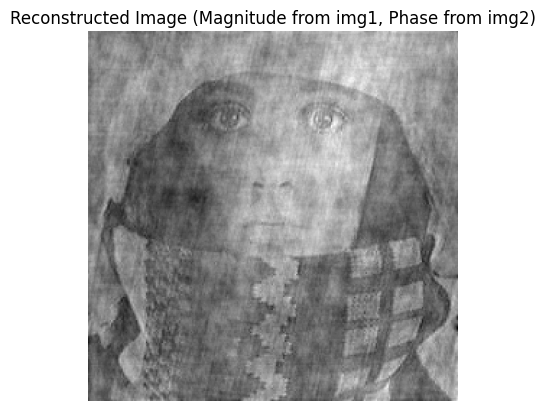

In [11]:
# Reconstruct an image using the magnitude from f1 and the phase from f2
img3 = np.real(np.fft.ifft2(np.abs(f1) * np.exp(1j * np.angle(f2))))

# Display the reconstructed image
plt.imshow(img3, cmap="gray")
plt.axis('off')
plt.title("Reconstructed Image (Magnitude from img1, Phase from img2)")
plt.show()

The reconstructed image retains the structure of the phase component. This demonstrates the significance of phase in preserving image details.

## 2. Frequency-Domain Filtering
### 2.1 Low-Pass Filtering
A low-pass filter allows low-frequency components (smooth regions) to pass while suppressing high-frequency components (edges and noise).

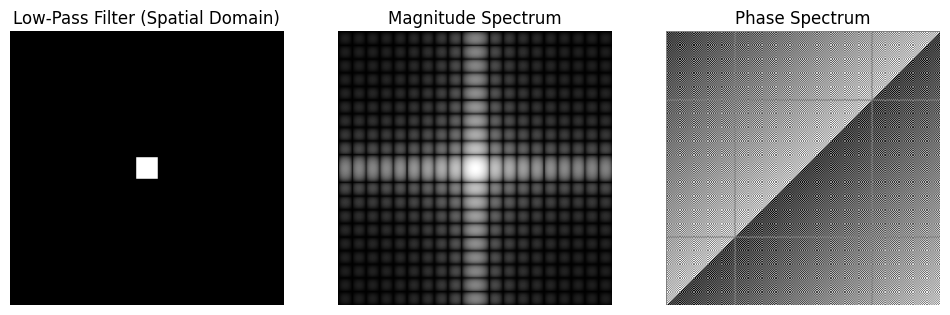

In [15]:
# Get image dimensions
h, w = img1.shape

# Initialize a low-pass filter with zeros
low_pass_filter = np.zeros((h, w))

# Define center of the frequency domain
center_h, center_w = h // 2, w // 2

# Define cutoff frequency for the low-pass filter
cutoff_frequency = 10

# Create a square low-pass filter mask
low_pass_filter[center_h - cutoff_frequency:center_h + cutoff_frequency, 
                center_w - cutoff_frequency:center_w + cutoff_frequency] = 1

# Compute FFT of the filter and shift zero frequency to center
fft_filter = np.fft.fftshift(np.fft.fft2(low_pass_filter))

# Compute magnitude and phase spectra
filter_mag = np.abs(fft_filter)  # Magnitude
filter_phase = np.angle(fft_filter)  # Phase

# Display filter and its frequency domain representations
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 8))

ax1.imshow(low_pass_filter, cmap="gray")
ax1.set_title("Low-Pass Filter (Spatial Domain)")
ax1.axis("off")

ax2.imshow(np.log(1 + filter_mag), cmap="gray")
ax2.set_title("Magnitude Spectrum")
ax2.axis("off")

ax3.imshow(filter_phase, cmap="gray")
ax3.set_title("Phase Spectrum")
ax3.axis("off")

plt.show()

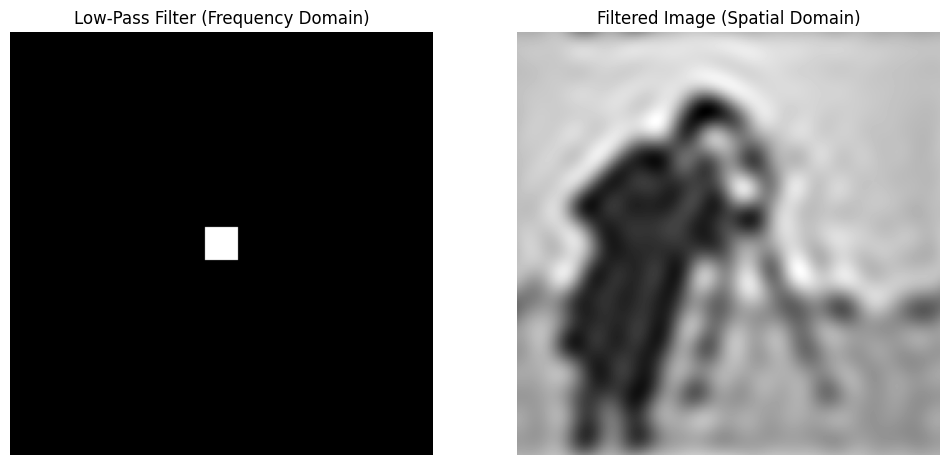

In [16]:
# Apply the low-pass filter in the frequency domain
filtered = fshift1 * low_pass_filter  

# Shift the filtered spectrum back
filtered_shifted = np.fft.ifftshift(filtered)  

# Compute the inverse FFT to reconstruct the filtered image
img_filtered = np.fft.ifft2(filtered_shifted).real  

# Display the low-pass filter and the filtered image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

ax1.imshow(low_pass_filter, cmap="gray")
ax1.set_title("Low-Pass Filter (Frequency Domain)")
ax1.axis("off")

ax2.imshow(img_filtered, cmap="gray")
ax2.set_title("Filtered Image (Spatial Domain)")
ax2.axis("off")

plt.show()

The filtered image appears blurred, as fine details (high frequencies) are removed.

### 2.2 High-Pass Filtering
A high-pass filter retains high-frequency components (edges and fine details) while suppressing low-frequency components.

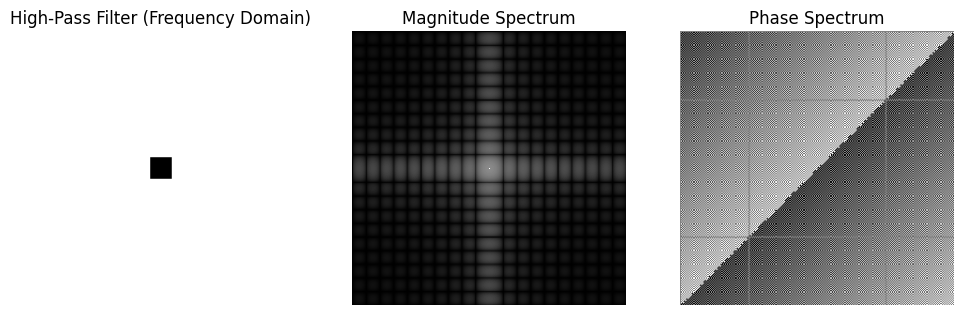

In [17]:
# Get image dimensions
h, w = img1.shape

# Create a high-pass filter (initially all ones)
high_pass_filter = np.ones((h, w))

# Define cutoff frequency for the filter
cutoff_frequency = 10

# Compute the cutoff region dynamically for both dimensions
c_x, c_y = w // 2 - cutoff_frequency, h // 2 - cutoff_frequency
high_pass_filter[c_y:-c_y, c_x:-c_x] = 0  # Set the low-frequency region to zero

# Compute FFT of the filter for visualization
fft_filter = np.fft.fftshift(np.fft.fft2(high_pass_filter))

# Compute magnitude and phase of the filter
filter_mag = np.abs(fft_filter)
filter_phase = np.angle(fft_filter)

# Display high-pass filter, magnitude spectrum, and phase spectrum
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 8))

ax1.imshow(high_pass_filter, cmap="gray")
ax1.set_title("High-Pass Filter (Frequency Domain)")
ax1.axis("off")

ax2.imshow(np.log(1 + filter_mag), cmap="gray")
ax2.set_title("Magnitude Spectrum")
ax2.axis("off")

ax3.imshow(filter_phase, cmap="gray")
ax3.set_title("Phase Spectrum")
ax3.axis("off")

plt.show()

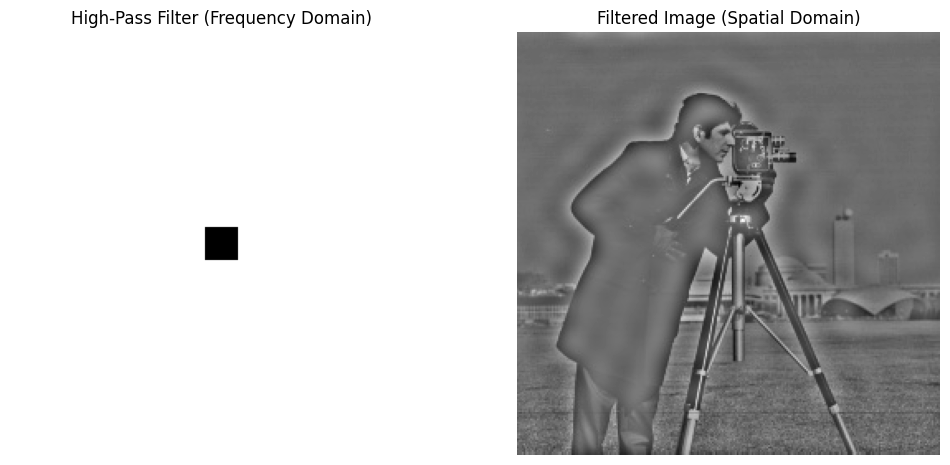

In [18]:
# Apply the high-pass filter in the frequency domain
filtered = fshift1 * high_pass_filter  

# Shift the frequency components back
filtered_shifted = np.fft.ifftshift(filtered)

# Compute the inverse Fourier Transform to get the filtered image
img_filtered = np.fft.ifft2(filtered_shifted).real  

# Display the high-pass filter and the filtered image
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))

ax1.imshow(high_pass_filter, cmap="gray")
ax1.set_title("High-Pass Filter (Frequency Domain)")
ax1.axis("off")

ax2.imshow(img_filtered, cmap="gray")
ax2.set_title("Filtered Image (Spatial Domain)")
ax2.axis("off")

plt.show()

The filtered image emphasizes edges and fine details.

## 3. Histogram Processing
### 3.1 Histogram Visualization
Histograms show the distribution of pixel intensities in an image. Examining histograms helps in understanding contrast and brightness.

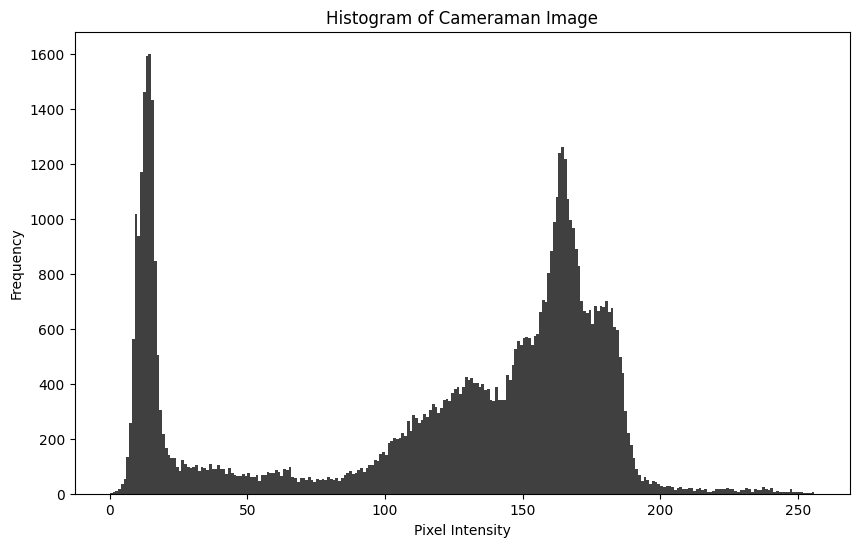

In [19]:
# Compute and display the histogram of the image
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(img1.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
ax.set_title("Histogram of Cameraman Image")
ax.set_xlabel("Pixel Intensity")
ax.set_ylabel("Frequency")

plt.show()

A **narrow histogram** indicates low contrast, meaning the pixel intensities are concentrated within a small range, resulting in a flat or dull appearance with minimal distinction between dark and bright areas.

A **skewed histogram** suggests unbalanced brightness, if shifted left, the image is predominantly dark (underexposed), while a shift to the right indicates excessive brightness (overexposed). A well-balanced histogram typically spans a wider range, ensuring better contrast and visibility of details.

### 3.2 Intensity Transformations (Brightness Adjustments)
We apply intensity transformations by shifting pixel values to the left (darker) or right (brighter).

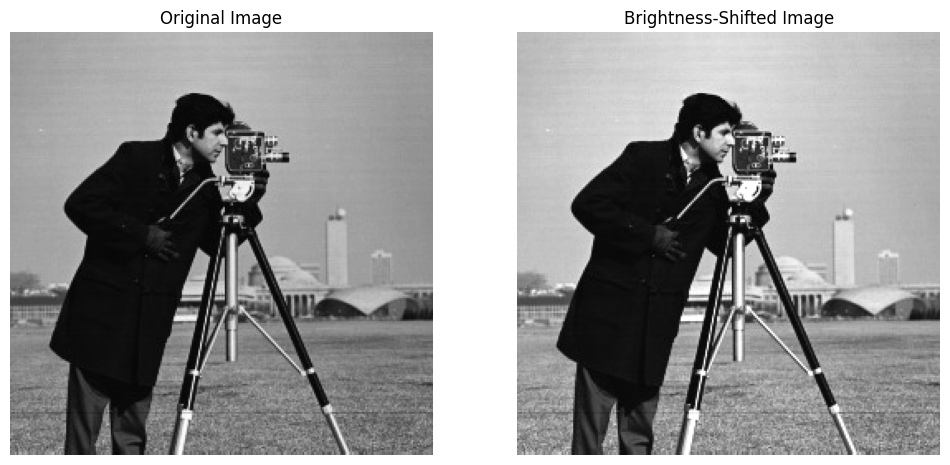

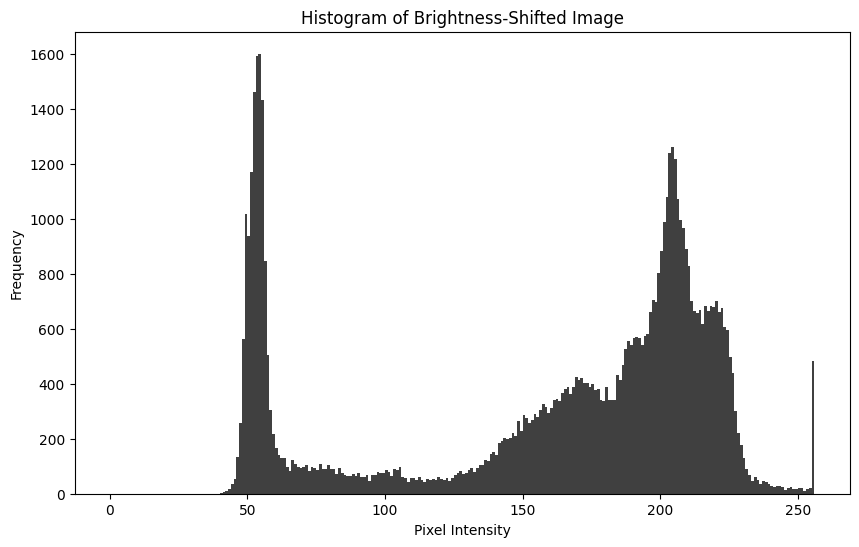

In [20]:
shift = 40  # Brightness shift value

# Add shift and ensure values remain in the valid range [0, 255]
translated_right = (img1.astype(np.int16) + shift).clip(0, 255).astype(np.uint8)

# Display original and shifted images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
ax1.imshow(img1, cmap='gray')
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(translated_right, cmap='gray')
ax2.set_title('Brightness-Shifted Image')
ax2.axis('off')

# Display histogram of the shifted image
fig2, ax3 = plt.subplots(figsize=(10, 6))
ax3.hist(translated_right.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
ax3.set_title('Histogram of Brightness-Shifted Image')
ax3.set_xlabel('Pixel Intensity')
ax3.set_ylabel('Frequency')

plt.show()

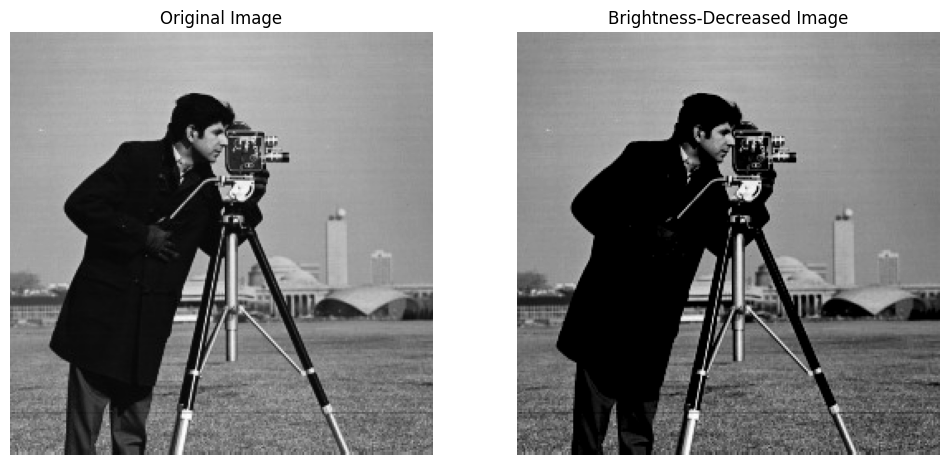

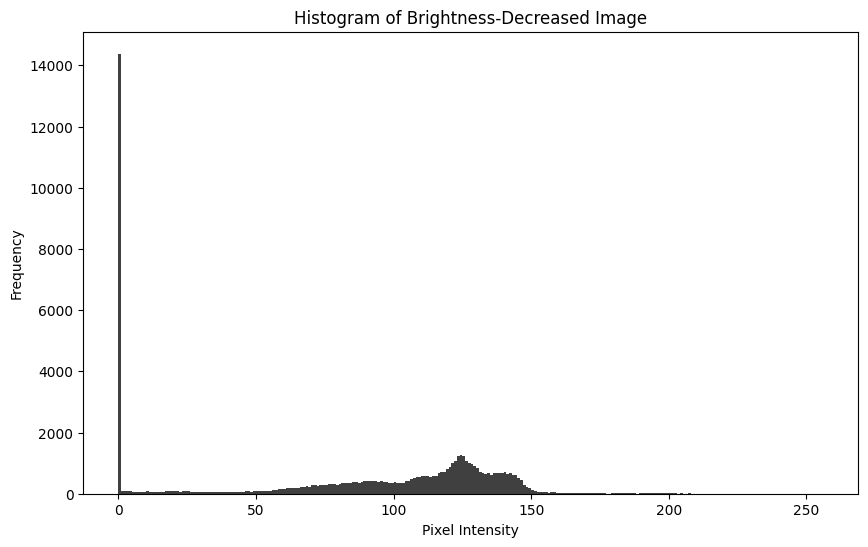

In [21]:
shift = 40  # Brightness shift value

# Decrease brightness and ensure values remain within [0, 255]
translated_left = (img1.astype(np.int16) - shift).clip(0, 255).astype(np.uint8)

# Display original and brightness-reduced images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
ax1.imshow(img1, cmap='gray')
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(translated_left, cmap='gray')
ax2.set_title('Brightness-Decreased Image')
ax2.axis('off')

# Display histogram of the brightness-decreased image
fig2, ax3 = plt.subplots(figsize=(10, 6))
ax3.hist(translated_left.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
ax3.set_title('Histogram of Brightness-Decreased Image')
ax3.set_xlabel('Pixel Intensity')
ax3.set_ylabel('Frequency')

plt.show()

### 3.3 Histogram Equalization
Histogram equalization enhances image contrast by redistributing intensity values to achieve a more uniform histogram.

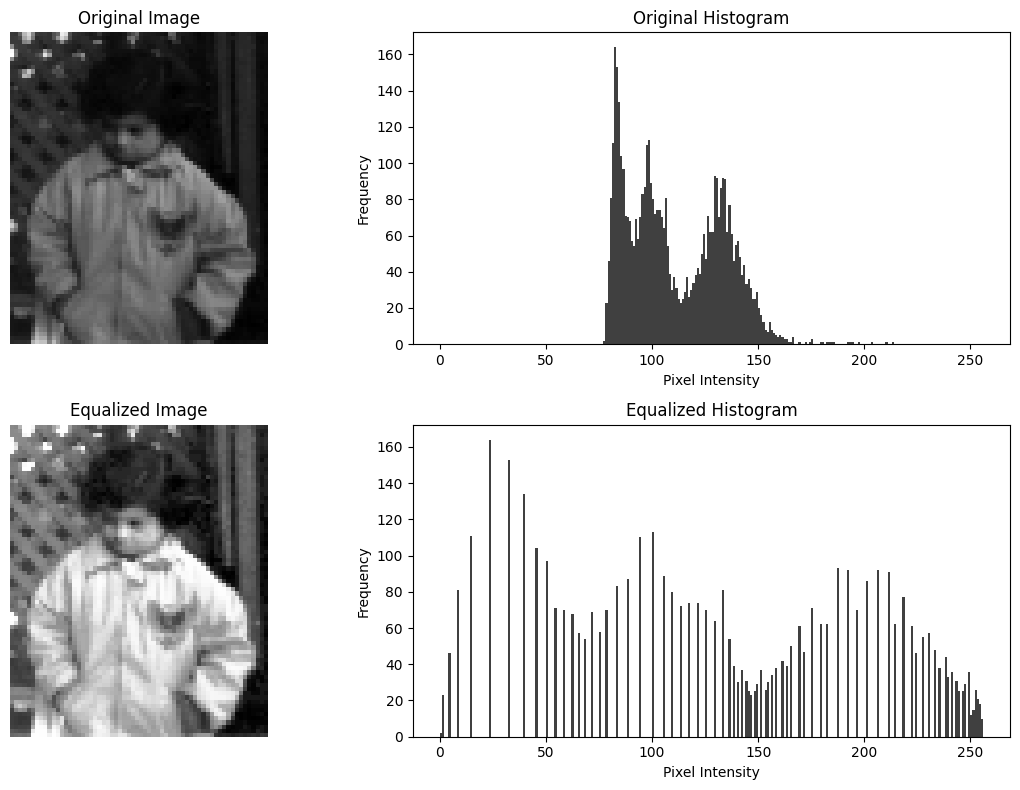

In [22]:
# Load grayscale image
img4 = cv2.imread("data/thumb_pout.png", cv2.IMREAD_GRAYSCALE)

# Apply histogram equalization
eq_img = cv2.equalizeHist(img4)

# Create subplots
fig, axis = plt.subplots(2, 2, figsize=(12, 8))

# Display original image
axis[0, 0].imshow(img4, cmap='gray')
axis[0, 0].set_title('Original Image')
axis[0, 0].axis('off')

# Display original histogram
axis[0, 1].hist(img4.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
axis[0, 1].set_title('Original Histogram')
axis[0, 1].set_xlabel('Pixel Intensity')
axis[0, 1].set_ylabel('Frequency')

# Display equalized image
axis[1, 0].imshow(eq_img, cmap='gray')
axis[1, 0].set_title('Equalized Image')
axis[1, 0].axis('off')

# Display equalized histogram
axis[1, 1].hist(eq_img.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
axis[1, 1].set_title('Equalized Histogram')
axis[1, 1].set_xlabel('Pixel Intensity')
axis[1, 1].set_ylabel('Frequency')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

Histogram equalization improves the image contrast by making the histogram more uniform and spreading it out over the full intensity range, which enhances the overall visibility of details in the image.